24RB1074 半田悠人


## 課題1：ソフトマージンSVMで二値分類

In [18]:
import numpy as np

# step1: データの生成
initial = np.random.randn(1000, 2)

class1 = initial[:500] + np.array([1, 1])
class_minus1 = initial[500:] + np.array([-1, -1])

data = np.vstack((class1, class_minus1))
labels = np.hstack((np.ones(500), -np.ones(500)))

#step2: ロス関数
def soft_margin_loss(x, y, w, b, C):
    norm = np.linalg.norm(w)
    hinge = np.maximum(0, 1 - y * (x @ w + b))

    return 0.5 * norm**2 + C * np.sum(hinge)

#step3: 勾配の計算
def soft_margin_loss_grad(x, y, w, b, C):
    norm = np.linalg.norm(w)
    hinge = np.maximum(0, 1 - y * (x @ w + b))

    dw = w - C * np.sum((hinge > 0)[:, np.newaxis] * y[:, np.newaxis] * x, axis=0)
    db = -C * np.sum((hinge > 0) * y)

    return dw, db

#step4: 勾配法
def train_svm(C=1.0, lr=0.01, epochs=100):
    w = np.zeros(2)
    b = 0
    
    loss_history = []
    boundaries = {}  # 初期、中期、最終の境界を保存

    for epoch in range(epochs):
        dw, db = soft_margin_loss_grad(data, labels, w, b, C)
        w = w - lr * dw
        b = b - lr * db
        
        # 損失を記録
        loss = soft_margin_loss(data, labels, w, b, C)
        loss_history.append(loss)
        
        # 初期、中期、最終の境界を保存
        if epoch == 0:
            boundaries['initial'] = (w.copy(), b)
        elif epoch == epochs // 2:
            boundaries['middle'] = (w.copy(), b)
        elif epoch == epochs - 1:
            boundaries['final'] = (w.copy(), b)

    return w, b, loss_history, boundaries

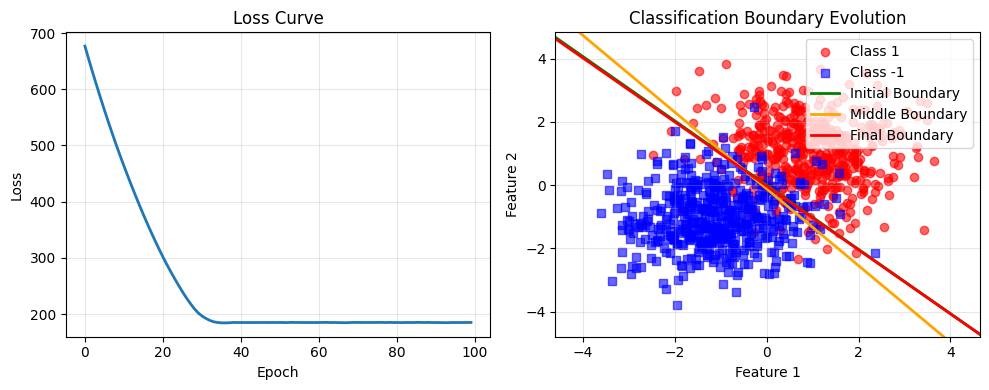

In [19]:
import matplotlib.pyplot as plt

# SVM訓練
w_final, b_final, loss_history, boundaries = train_svm(C=1.0, lr=0.01, epochs=100)

#step5: 可視化
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# プロット1: 損失曲線
axes[0].plot(loss_history, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].grid(True, alpha=0.3)

# プロット2: 初期と中期と最終の境界
ax_main = axes[1]

# データをプロット
ax_main.scatter(class1[:, 0], class1[:, 1], c='red', marker='o', label='Class 1', alpha=0.6)
ax_main.scatter(class_minus1[:, 0], class_minus1[:, 1], c='blue', marker='s', label='Class -1', alpha=0.6)

# 分類境界を描画
x_min, x_max = data[:, 0].min() - 1, data[:, 0].max() + 1
y_min, y_max = data[:, 1].min() - 1, data[:, 1].max() + 1
xx = np.linspace(x_min, x_max, 100)

colors_boundary = {'initial': 'green', 'middle': 'orange', 'final': 'red'}
labels_boundary = {'initial': 'Initial', 'middle': 'Middle', 'final': 'Final'}

for phase, (w, b) in boundaries.items():
    if w[1] != 0:
        yy = -(w[0] * xx + b) / w[1]
        ax_main.plot(xx, yy, color=colors_boundary[phase], linewidth=2, 
                    label=f'{labels_boundary[phase]} Boundary')

ax_main.set_xlim(x_min, x_max)
ax_main.set_ylim(y_min, y_max)
ax_main.set_xlabel('Feature 1')
ax_main.set_ylabel('Feature 2')
ax_main.set_title('Classification Boundary Evolution')
ax_main.legend()
ax_main.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 課題2：特徴抽出＋ソフトマージンSVM

In [20]:
# step1:データ生成
def make_circles(a, b, num_samples=1000):
    theta = np.random.uniform(0, 2 * np.pi, num_samples)
    circles = np.column_stack((a * np.cos(theta), b * np.sin(theta)))

    return circles

circles_a = make_circles(1, 1, num_samples=500)
circles_b = make_circles(2, 2, num_samples=500)

data_circles = np.vstack((circles_a, circles_b))
labels_circles = np.hstack((np.ones(500), -np.ones(500)))


# step2:特徴写像の定義
def phi(x):
    x = np.asarray(x)
    return np.column_stack((x[:, 0], x[:, 1], x[:, 0]**2 + x[:, 1]**2))

phi_data = phi(data_circles)


# step3-5:学習関数
def train_svm_mapped(X, y, C=1.0, lr=0.001, epochs=1000):
    num_features = X.shape[1]
    w = np.zeros(num_features)
    b = 0
    
    loss_history = []
    boundaries = {}

    for epoch in range(epochs):
        dw, db = soft_margin_loss_grad(X, y, w, b, C)
        w = w - lr * dw
        b = b - lr * db
        
        # 損失の記録
        loss = soft_margin_loss(X, y, w, b, C)
        loss_history.append(loss)
        
        if epoch == 0:
            boundaries['initial'] = (w.copy(), b)
        elif epoch == epochs // 2:
            boundaries['middle'] = (w.copy(), b)
        elif epoch == epochs - 1:
            boundaries['final'] = (w.copy(), b)

    return w, b, loss_history, boundaries

# 学習の実行
w_final, b_final, loss_history, boundaries = train_svm_mapped(
    X=phi_data, 
    y=labels_circles, 
    C=1.0, 
    lr=0.001, 
    epochs=500
)

print(f"最終的な w: {w_final}")
print(f"最終的な b: {b_final}")
print(f"最終ロス: {loss_history[-1]:.4f}")

最終的な w: [-0.01593281 -0.01198762 -1.00910114]
最終的な b: 2.601
最終ロス: 0.5093


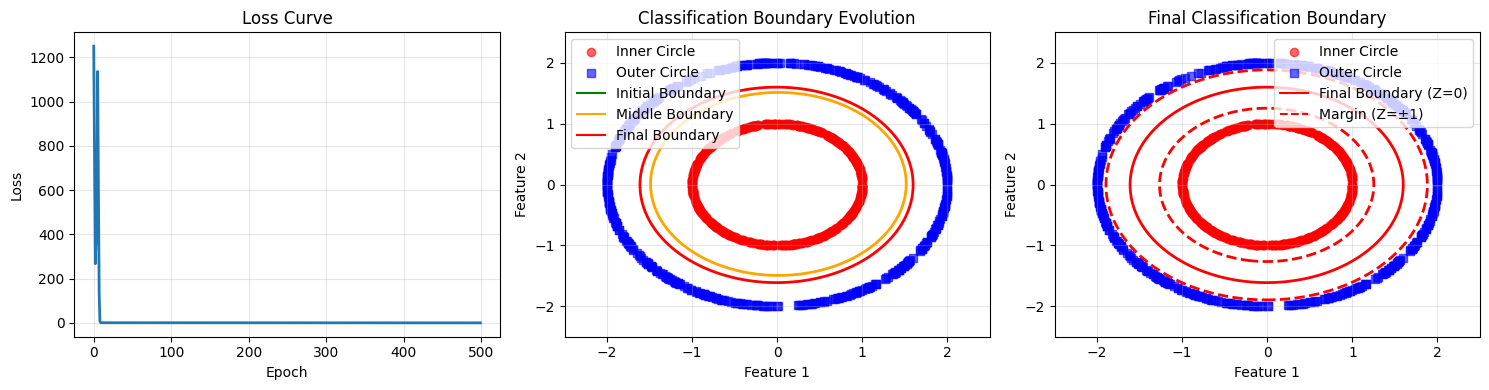

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#step6:結果の可視化
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# ---------------------------------------------------
# プロット1: 損失曲線
# ---------------------------------------------------
axes[0].plot(loss_history, linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss Curve')
axes[0].grid(True, alpha=0.3)

# ---------------------------------------------------
# contourプロット用のメッシュグリッド作成（2D空間）
# ---------------------------------------------------
x_min, x_max = data_circles[:, 0].min() - 0.5, data_circles[:, 0].max() + 0.5
y_min, y_max = data_circles[:, 1].min() - 0.5, data_circles[:, 1].max() + 0.5
# 100x100の細かい網目を作る
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# 網目のすべての点(10000個)を1列に並べる (10000, 2)
grid_points = np.c_[xx.ravel(), yy.ravel()]
# メッシュ上のすべての点にも phi(x) を適用して3次元空間に持ち上げる！ (10000, 3)
grid_phi = phi(grid_points)

# ---------------------------------------------------
# プロット2: 初期と中期と最終の境界 (非線形版)
# ---------------------------------------------------
ax_main = axes[1]

# 元の2次元データをプロット
ax_main.scatter(circles_a[:, 0], circles_a[:, 1], c='red', marker='o', label='Inner Circle', alpha=0.6)
ax_main.scatter(circles_b[:, 0], circles_b[:, 1], c='blue', marker='s', label='Outer Circle', alpha=0.6)

colors_boundary = {'initial': 'green', 'middle': 'orange', 'final': 'red'}
labels_boundary = {'initial': 'Initial', 'middle': 'Middle', 'final': 'Final'}

for phase, (w, b) in boundaries.items():
    # メッシュ上のすべての点で w^T phi(x) + b を計算
    Z = grid_phi @ w + b
    Z = Z.reshape(xx.shape) # 100x100の形に戻す
    
    # 高さが 0 の場所（決定境界）に等高線を引く
    ax_main.contour(xx, yy, Z, levels=[0], colors=[colors_boundary[phase]], linewidths=2)
    # ※凡例(legend)用にダミーの線を引く
    ax_main.plot([], [], color=colors_boundary[phase], label=f'{labels_boundary[phase]} Boundary')

ax_main.set_xlim(x_min, x_max)
ax_main.set_ylim(y_min, y_max)
ax_main.set_xlabel('Feature 1')
ax_main.set_ylabel('Feature 2')
ax_main.set_title('Classification Boundary Evolution')
ax_main.legend()
ax_main.grid(True, alpha=0.3)

# ---------------------------------------------------
# プロット3: 最終の境界とマージン
# ---------------------------------------------------
ax_final = axes[2]

# 元の2次元データをプロット
ax_final.scatter(circles_a[:, 0], circles_a[:, 1], c='red', marker='o', label='Inner Circle', alpha=0.6)
ax_final.scatter(circles_b[:, 0], circles_b[:, 1], c='blue', marker='s', label='Outer Circle', alpha=0.6)

w_final_boundary, b_final_boundary = boundaries['final']

# 最終的な重みで全グリッドの値を計算
Z_final = grid_phi @ w_final_boundary + b_final_boundary
Z_final = Z_final.reshape(xx.shape)

# 決定境界 (Z=0) は実線、マージン境界 (Z=-1, Z=1) は点線で描画するおまけを追加
contour = ax_final.contour(xx, yy, Z_final, levels=[-1, 0, 1], 
                           linestyles=['--', '-', '--'], colors='red', linewidths=2)
ax_final.plot([], [], color='red', linestyle='-', label='Final Boundary (Z=0)')
ax_final.plot([], [], color='red', linestyle='--', label='Margin (Z=±1)')

ax_final.set_xlim(x_min, x_max)
ax_final.set_ylim(y_min, y_max)
ax_final.set_xlabel('Feature 1')
ax_final.set_ylabel('Feature 2')
ax_final.set_title('Final Classification Boundary')
ax_final.legend(loc='upper right')
ax_final.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SVM学習結果の可視化に対する観察と考察
## 課題1:
### 1. 損失曲線の観察
* **収束の早さ:** 学習開始時に約600だった損失が急激に減少し、Epoch 35〜40付近で約170程度で収束している。
* **学習の完了:** 損失が途中で振動したり発散したりすることなく、ハイパーパラメータが適切に設定され、勾配降下法による最適化が完了している。

### 2. 決定境界の移動
* **境界線の移動:** 初期状態から、学習の中盤、そして最終状態へと、決定境界が2つのクラスをより綺麗に分割する位置へとシフトしていく様子がグラフからわかる。
* **中盤以降の微調整:** 中盤と最終の決定境界が非常に近い位置にあることは、損失曲線がEpoch 40以降で平坦になっていることに整合している。

## 課題2:
### 1. 損失曲線の観察
* **収束とゼロ損失:** 学習開始直後に損失が1200以上から一気に急降下し、数エポック〜十数エポックで0に到達している。
* **分類精度:** 損失が0に張り付いており、特徴写像を通したことで、データが線形分離可能な状態になり、ヒンジロスが完全に消滅したことを示している。

### 2. 決定境界の移動
* **境界の拡大（オレンジ線 → 赤線）:** 学習が進むにつれて、決定境界が外側へと拡大していく様子がグラフからわかる。

### 3. 最終決定境界とマージン
* **完璧な非線形分離:** 最終的な決定境界が、内側と外側のクラスの間の中央の空白地帯に円として引かれている。
* **サポートベクトルの可視化:** マージン境界に注目すると、外側のマージン線は青クラスの一番内側のデータ点にぴったりと接している。


## 3. 総合考察
* **データの性質:** 課題1について、プロットされたデータ点を見ると、赤（Class 1）と青（Class -1）のクラスタの境界付近でデータが入り混じっており、1本の直線で完全に分けることは不可能なデータセットである。同様に課題2のデータセットも直線による分離が不可能であるが、$x_1^2 + x_2^2$ といった非線形な特徴量を追加して高次元に持ち上げたことで線形分離可能な高次元データに変換できた。


## AI利用について
本演習課題の実施にあたり、以下の通りAIを活用した。

* 関数の調査・学習

    * 実現したい処理を行える関数の選定から、必要な引数、内部の処理内容、返り値についてAIに質問し、理解を深めた上で実装と確認を行った。
    * 調査した主な関数・メソッド: `numpy.vstack`, `numpy.hstack`, `numpy.linalg.norm`

* グラフのプロット（Copilotの活用）

    * 元の2次元空間に非線形な決定境界を描画するためのコード作成にCopilotを活用した。
    * 生成されたコードと出力されたグラフは自分で内容の確認と検証を行った。

* アルゴリズムの理論理解と実装サポート

    * 数式とPythonプログラムの対応関係についてAIに質問し、理解を深めた上でSVMの学習関数の実装を行った。
    * 特徴写像を用いた非線形SVMへのコード拡張について、データの次元数に合わせるためのサポートを受けた。